# Relative Elevation Model Visualization - River of Interest 

##### Author: Will Wright
##### Based on "Tutorial: Relative Elevation Model Visualization" by [Dahn](https://twitter.com/DahnJahn) and tutorial by Matt Forest
##### Above tutorial recreates the [Ivalo River Geomorphology](https://dancoecarto.com/ivalo-river-geomorphology)

# Setup

In [38]:
!pip install osmnx scipy xarray rioxarray matplotlib datashader geojson -q

In [39]:
pip install xarray-spatial -q

Note: you may need to restart the kernel to use updated packages.


In [40]:
from pathlib import Path 
from IPython.core.display import Video 

import numpy as np 
import pandas as pd 
import geopandas as gpd      # Vector data handling 
import osmnx as ox           # Downloading data from OSM 

from shapely.geometry import box 
from scipy.spatial import cKDTree as KDTree   # For Inverse Distance Weight calculation 

import xarray as xr 
import xrspatial             # Hillshading 
import rioxarray             # Working with geospatial data in xarray 

import matplotlib.pyplot as plt 
from datashader.transfer_functions import shade, stack 

# Step 1: Download & Load Digital Elevation Model (DEM) 

##### Select an area of interest 
* [USGS LidarExplorer ](https://apps.nationalmap.gov/lidar-explorer/#/)

In [41]:
dem = rioxarray.open_rasterio('data/USGS_1_n45w073_20260126.tif')

##### Make DEM smaller and clip to focus area 

In [42]:
import geojson 

##### Choose a location within the boundaries of the USGS data 
* [Bounding Box](https://boundingbox.klokantech.com/)

In [220]:
geom = '''{"type": "Polygon",
                "coordinates": [[
                [-73.0212210666,44.2360054346],
                [-72.4597521753,44.2360054346],
                [-72.4597521753,44.4223327865],
                [-73.0212210666,44.4223327865],
                [-73.0212210666,44.2360054346]]]}'''

In [221]:
cropping_geometries = [geojson.loads(geom)]    # Folding geometry into an array 
cropped = dem.rio.clip(geometries=cropping_geometries, crs=4326)    # Rio feature; clips DEM to desired size and scale

In [222]:
cropped = cropped.coarsen(x=3, boundary='trim').mean().coarsen(y=3, boundary='trim').mean()   # Coarsening, trimming the DEM

##### Now we plot the DEM 

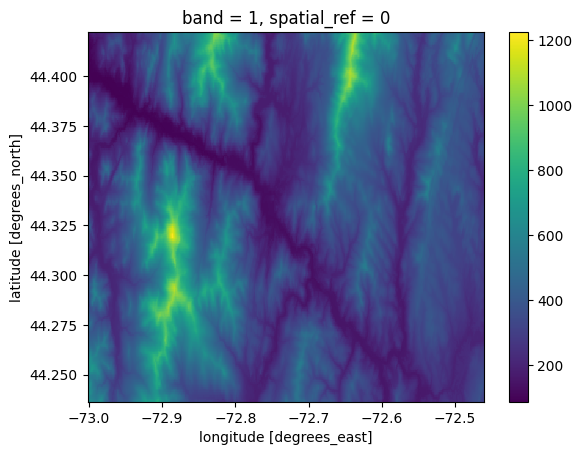

In [223]:
cropped.squeeze().plot.imshow()

# Step 2: Fetch coordinates of the river 

In [224]:
river = ox.geocode_to_gdf('Winooski River', which_result=1)   # Geocoding the Winooski River 
river = river.to_crs(cropped.rio.crs)    # Grabbing the coordinate reference system from raster data and applying it to the river

##### Let's plot the river

<Axes: >

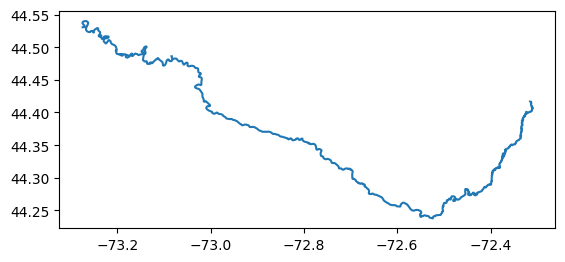

In [225]:
river.plot()   # Plots the whole Winooski River

# Step 3: Cut to the area of interest 

##### River

In [226]:
cropped.rio.bounds()   # Find bounding box of the raster data 

(-73.00138888870498, 44.2366666668587, -72.46027777757591, 44.42194444464263)

In [227]:
bounds = cropped.rio.bounds()   # Place bounds into a variable called 'bounds'
xmin, ymin, xmax, ymax = bounds

In [228]:
river = river.clip(bounds)

In [229]:
river.geometry   # Data frame and geomtery of river

0    MULTILINESTRING ((-72.46028 44.27124, -72.4606...
Name: geometry, dtype: geometry

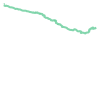

In [230]:
river_geom = river.geometry.iloc[0]
river_geom 

##### DEM 

In [231]:
cropped = cropped.sel(y=slice(ymax, ymin), x=slice(xmin, xmax))   # Crop bounding box

##### Check everything together 

<Axes: title={'center': 'band = 1, spatial_ref = 0'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

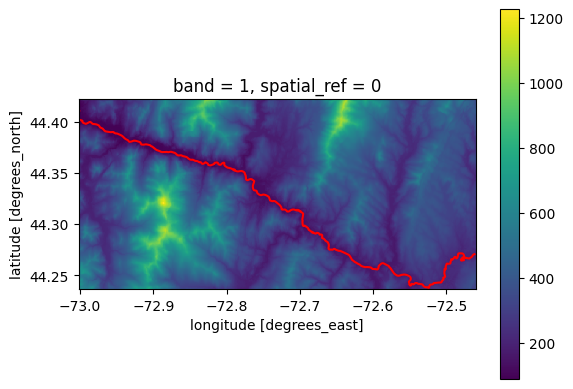

In [232]:
fig, ax = plt.subplots()   # Passing the same ax to multiple plot calls lets you overlay multiple datasets on the same map.
cropped.squeeze().plot.imshow(ax=ax)  # squeeze drops unnecessary extra dimension
river.plot(ax=ax, color='red')

##### Above we have the DEM bounded area of interest and the Winooski River highlighted in red

# Step 4: Calculate REM

###### To calculate REM, we need to
1. Sample the elevation along the river 
2. Interpolate the sampled elevation values to create a 2D elevation raster 
3. Subtract the interpolated elevation raster from the DEM 


## 4.1 Sample 

##### Extract coordinates as[ DataArray](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.html)

In [233]:
import shapely 

def split_coords(geom):      # Takes any Shapely geometry and =returns its coordinates split into x and y lists
    x = []
    y = []
    for i in shapely.get_coordinates(geom):
        x.append(i[0])
        y.append(i[1])
    return x, y

In [234]:
xs, ys = split_coords(river_geom)
xs, ys = xr.DataArray(xs, dims='z'), xr.DataArray(ys, dims='z')   # This creates a 1‑D xarray DataArray

##### Use xarray's [interp](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.interp.html) to extract the river's elevation. We interpolate a DataArray onto new coordinates 

In [235]:
sampled = cropped.interp(x=xs, y=ys, method='nearest').dropna(dim='z')

In [236]:
cropped  # We can see that we have xarray.DataArray

<xarray.DataArray (band: 1, y: 223, x: 650)> Size: 580kB
array([[[130.3532  , 142.25563 , 157.20415 , ..., 377.08914 ,
         356.6316  , 365.25693 ],
        [117.73798 , 131.16241 , 140.62543 , ..., 371.22763 ,
         369.07495 , 360.66248 ],
        [108.57978 , 114.644714, 124.253365, ..., 381.4636  ,
         368.58704 , 340.68457 ],
        ...,
        [652.02716 , 628.3699  , 617.9453  , ..., 320.91684 ,
         323.09814 , 327.36487 ],
        [666.6633  , 639.9864  , 626.36816 , ..., 320.7601  ,
         325.4819  , 331.79846 ],
        [668.706   , 647.3925  , 635.17847 , ..., 322.97842 ,
         329.87805 , 336.27658 ]]], shape=(1, 223, 650), dtype=float32)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 2kB 44.42 44.42 44.42 44.42 ... 44.24 44.24 44.24
  * x            (x) float64 5kB -73.0 -73.0 -73.0 ... -72.46 -72.46 -72.46
    spatial_ref  int64 8B 0
Attributes: (12/13)
    BandDefinitionKeyword:     *
    DataType:                  *
    AREA_OR_POINT:             Area
    LAYER_TYPE:                *
    RepresentationType:        *
    STATISTICS_MAXIMUM:        1338.6086425781
    ...                        ...
    STATISTICS_MINIMUM:        55.679981231689
    STATISTICS_STDDEV:         156.93877720067
    STATISTICS_VALID_PERCENT:  100
    scale_factor:              1.0
    add_offset:                0.0
    _FillValue:                -999999.0

## 4.2 Interpolate

##### Prepare data for the interpolation

##### We are creating three things:
1. A 2D array of (x, y) river sample points (turned into NumPy arrays)
2. A 2D array of (x, y) coordinates for every DEM pixel
3. A 1D array of values sampled along the river

In [237]:
# Sampled river coordinates 
c_sampled = np.vstack([sampled.coords[c].values for c in ('x', 'y')]).T 

# All (x, y) coordinates of the original DEM 
c_x, c_y = [cropped.coords[c].values for c in ('x', 'y')]
c_interpolate = np.dstack(np.meshgrid(c_x, c_y)).reshape(-1, 2)

# Sampled values 
values = sampled.values.ravel()


In [238]:
c_sampled   # To see output of step 1

array([[-72.4605954,  44.271075 ],
       [-72.4611237,  44.2708746],
       [-72.4614674,  44.2707736],
       ...,
       [-72.6836567,  44.2922397],
       [-72.6838475,  44.2925244],
       [-72.6839522,  44.2928193]], shape=(931, 2))

In [239]:
c_interpolate   # To see output of step 2

array([[-73.00125   ,  44.42180556],
       [-73.00041667,  44.42180556],
       [-72.99958333,  44.42180556],
       ...,
       [-72.46208333,  44.23680556],
       [-72.46125   ,  44.23680556],
       [-72.46041667,  44.23680556]], shape=(144950, 2))

In [240]:
values   # To see output of step 3

array([203.85063 , 204.229   , 204.229   , 207.34747 , 207.34747 ,
       204.71953 , 203.33311 , 203.33311 , 204.96918 , 204.96918 ,
       202.8133  , 202.8133  , 204.6757  , 203.38525 , 202.71106 ,
       202.71106 , 202.58484 , 202.83589 , 202.83589 , 202.83589 ,
       202.74437 , 202.74437 , 202.34625 , 202.23152 , 202.23152 ,
       202.33662 , 202.33662 , 202.33662 , 202.54262 , 202.13554 ,
       202.13554 , 202.13554 , 202.13554 , 204.99243 , 204.99243 ,
       207.64894 , 207.64894 , 207.49962 , 202.89467 , 202.04454 ,
       202.04454 , 202.04454 , 205.18489 , 205.18489 , 201.84761 ,
       201.84761 , 201.84761 , 203.346   , 200.56781 , 200.56781 ,
       201.8952  , 201.8952  , 200.56781 , 200.56781 , 200.56781 ,
       203.346   , 212.5915  , 209.5066  , 204.78552 , 204.78552 ,
       204.78552 , 209.55731 , 209.55731 , 202.53194 , 215.88731 ,
       215.88731 , 202.53194 , 206.71922 , 206.71922 , 206.71922 ,
       203.36086 , 201.85359 , 201.85359 , 203.51949 , 202.251

##### Perform the interpolation. Here we use a simple impplementation of Inverse Distance Weighting ([IDW](https://gisgeography.com/inverse-distance-weighting-idw-interpolation/)), which averages the 5 nearest points, weighted by inverse distance 

##### General IDW formula: 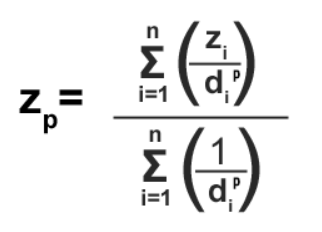

In [241]:
tree = KDTree(c_sampled)

In [242]:
tree

In [243]:
# IDW interpolation 
distances, indices = tree.query(c_interpolate, k=50)   # Finds the 50 nearest river points to each DEM cell (can adjust)

weights = 1 / distances 
weights = weights / weights.sum(axis=1).reshape(-1, 1)   # Computes distance‑based weights (see formula above)

interpolated_values = (weights * values[indices]).sum(axis=1)   # Computes a weighted average of river values at each DEM location

##### We create a DataArray out of the interpolated values
1. Turns your 1‑D interpolated values back into a 2‑D raster
2. Wraps the result in an xarray.DataArray
3. Assigns proper spatial coordinates (x, y)

In [244]:
elevation_raster = xr.DataArray(
    interpolated_values.reshape((len(c_y), len(c_x))).T, dims=('x', 'y'), coords={'x': c_x, 'y': c_y}
)

In [245]:
elevation_raster

<xarray.DataArray (x: 650, y: 223)> Size: 1MB
array([[ 90.72177729,  90.69752211,  90.66974637, ...,  92.99260807,
         92.99279325,  92.99297486],
       [ 90.72867008,  90.70500453,  90.67791579, ...,  92.99314026,
         92.99332083,  92.99349788],
       [ 90.73779103,  90.71518944,  90.6894114 , ...,  92.99367619,
         92.99385207,  92.99402448],
       ...,
       [203.92252887, 203.9225377 , 203.92254683, ..., 203.54390142,
        203.62545948, 203.62724983],
       [203.92271373, 203.92272459, 203.92273578, ..., 203.42364798,
        203.4250601 , 203.54562378],
       [203.92289824, 203.92291112, 203.92292436, ..., 203.37189109,
        203.41523434, 203.41646993]], shape=(650, 223))
Coordinates:
  * x        (x) float64 5kB -73.0 -73.0 -73.0 -73.0 ... -72.46 -72.46 -72.46
  * y        (y) float64 2kB 44.42 44.42 44.42 44.42 ... 44.24 44.24 44.24 44.24

<Axes: xlabel='x', ylabel='y'>

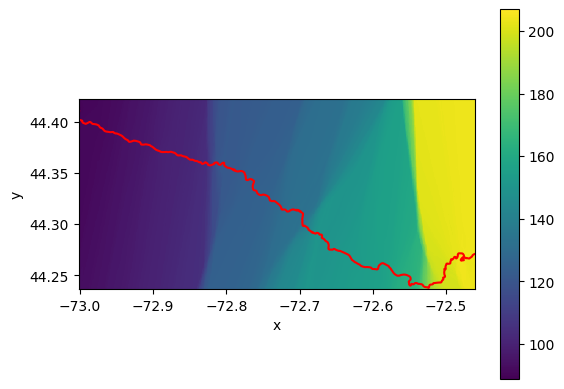

In [246]:
fig, ax = plt.subplots()
elevation_raster.transpose().plot.imshow(ax=ax)
river.plot(ax=ax, color='red')

## 4.3 Calculate 

In [247]:
rem = cropped - elevation_raster   # Subtract original (cropped) data from the elevation raster 

# Step 5: Visualize 

##### Let's make some sick REM visualizations!

In [248]:
colors = ['#f2f7fb', '#81a8cb', '#37123d']

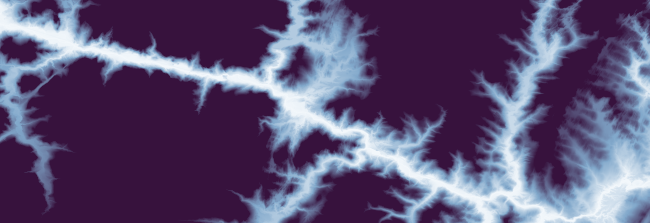

In [253]:
shade(rem.squeeze().isel(y=slice(None, None, -1)),
      cmap=colors,
      span=[0, 200],
      how='linear')

##### We can also visualize the DEM along with the REM

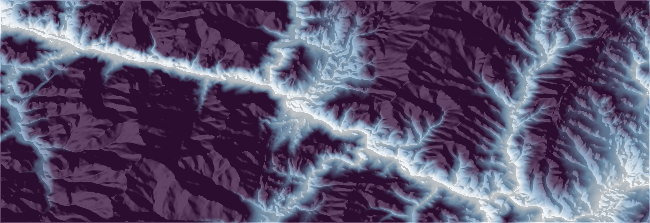

In [254]:
a = shade(xrspatial.hillshade(cropped.squeeze(), angle_altitude=1, azimuth=310), cmap=['black', 'white'], how='linear')
b = shade(rem.squeeze().isel(y=slice(None, None, -1)), cmap=colors, span=[0, 200], how='linear', alpha=200)
stack(a, b)